<img src="../res/logo.jpg" alt="Volcanicus" width="50%">

# Volcanicus tutorial

`volcanicus` wraps per-volcano deformation/residual measurements — one row per date/direction, one column per distance bin — in a `Volcano` object, taking care of dtype normalization and offering quick summary, statistics and plotting helpers on top of the pandas stack.

This notebook walks through:

1. Loading a bundled dataset
2. Inspecting the normalized `DataFrame`
3. Summarizing measurements with `Volcano.radial_profile()`
4. Plotting with the `.plot` accessor
5. Computing statistics with the `.stats` accessor


In [1]:
import volcanicus

volcanicus.__all__

['Volcano',
 'normalize_dataframe',
 'read_csv',
 'PlotAccessor',
 'StatsAccessor',
 'datasets']

## 1. Loading a bundled dataset

`volcanicus.datasets` ships a few example datasets, loadable by name.

In [2]:
volcanicus.datasets.available()

['copahue', 'etna', 'stromboli']

In [3]:
etna = volcanicus.datasets.load("etna")
etna

dates,99
missing,4315
registers,790


You can also build a `Volcano` from your own CSV file, either with the classmethod or the module-level shortcut:

```python
volcano = volcanicus.Volcano.from_csv("measurements.csv", volcano_name="Copahue")
volcano = volcanicus.read_csv("measurements.csv", volcano_name="Copahue")
```

The CSV is expected to have a `date` column, `center_lat`/`center_long`, a `direction` column, and one column per distance bin (everything else).

## 2. Inspecting the normalized `DataFrame`

`Volcano.__init__` normalizes dtypes on the way in: `date` is parsed as `datetime`, `center_lat`/`center_long` and the distance-bin columns as numeric, and `direction` as a category. `.to_dataframe()` always returns a copy, so the internal state can't be mutated from the outside.

In [ ]:
etna.to_dataframe().head()

In [ ]:
etna.to_dataframe().dtypes.head()

## 3. Summarizing measurements

`radial_profile()` averages the measurements over dates, per direction, producing one row per direction with the mean of every distance bin — the spatial curve, residual vs. distance.

`temporal_profile()` is its mirror: it averages over distance bins instead, producing one row per date with one column per direction — the temporal curve, residual vs. date.

In [6]:
etna.radial_profile().iloc[:, :6]

,15m,45m,75m,105m,135m,165m
direction,,,,,,
E,0.371373,0.272800,0.189716,0.142984,0.116166,0.094440
N,0.247392,0.196262,0.127873,0.093690,0.058153,0.042932
NE,0.300232,0.277657,0.195775,0.142963,0.111649,0.089847
NO,0.275927,0.219451,0.171200,0.105266,0.094334,0.088870
O,0.356040,0.308743,0.204983,0.138558,0.120303,0.096544
S,0.289061,0.284103,0.210740,0.165876,0.126052,0.100131
SE,0.317587,0.293560,0.219379,0.180023,0.152292,0.123560
SO,0.411945,0.296544,0.232454,0.164477,0.131767,0.103760


In [7]:
etna.temporal_profile().iloc[:5, :6]

direction,E,N,NE,NO,O,S
date,,,,,,
2000-07-26,0.056967,0.029077,0.045677,0.029207,0.048990,0.044527
2001-06-27,0.107037,0.004512,0.063200,0.055097,0.032279,0.059103
2001-07-13,0.049444,0.033950,0.179943,0.108969,0.096848,0.013970
2001-07-29,0.053738,0.053427,0.082808,0.050145,0.059545,0.782550
2001-08-30,0.055833,0.022893,0.059041,0.065020,0.000755,0.065410


## 4. Plotting with `.plot`

The `.plot` accessor follows the same pattern used across the library (`AccessorABC`): it's callable, dispatching to the method named `kind` (`"radial_profile"` by default), and its methods can also be called directly.

<Axes: title={'center': 'etna: residual vs. distance by direction'}, xlabel='Distance (m)', ylabel='Residual'>

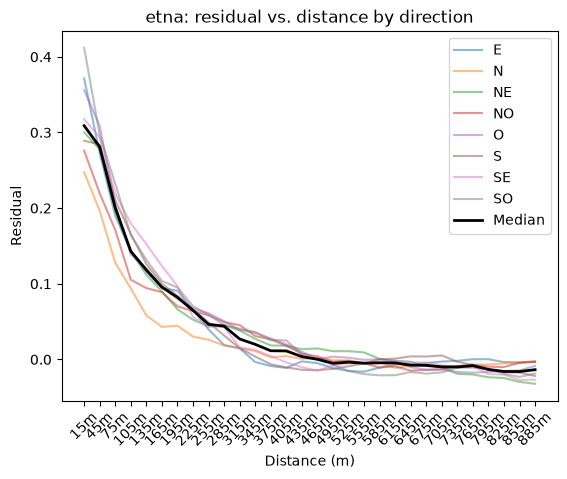

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

etna.plot.radial_profile()

The per-direction lines show `std` error bars when `std=True`, and the aggregate median line can be turned off with `median=False`:

<Axes: title={'center': 'etna: residual vs. distance by direction'}, xlabel='Distance (m)', ylabel='Residual'>

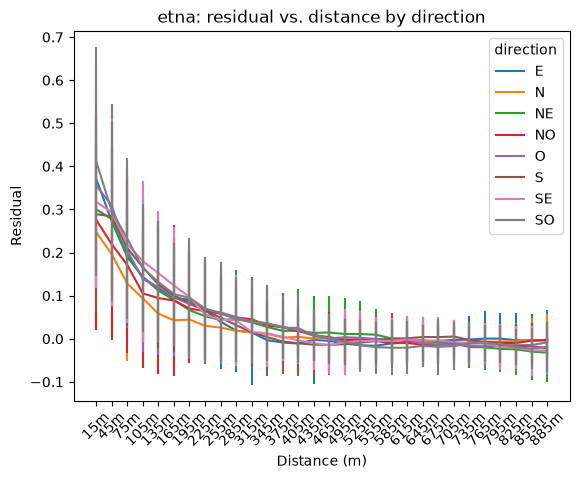

In [9]:
plt.figure()
etna.plot.radial_profile(std=True, median=False)

Since `PlotAccessor` is callable, the same plot can be produced with the default kind:

```python
etna.plot()  # same as etna.plot.radial_profile()
etna.plot("radial_profile", median=False)
```


`temporal_profile()` is the plot's temporal mirror: same two-layer plot (one line per direction, plus an aggregate median line), but with `date` on the x-axis. Error bars on the per-direction lines come from the spread across distance bins at each date, instead of across dates at each distance bin.

<Axes: title={'center': 'etna: residual vs. date by direction'}, xlabel='Date', ylabel='Residual'>

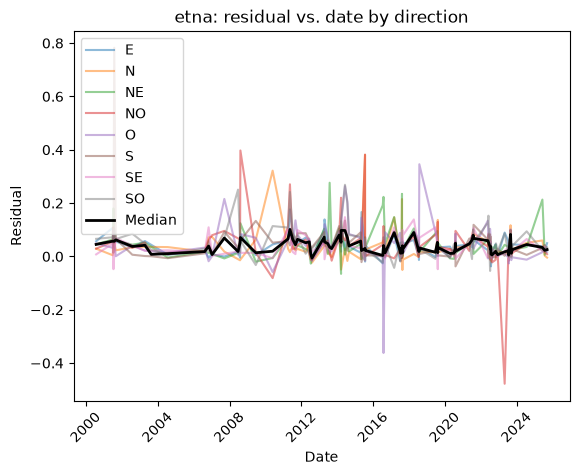

In [10]:
plt.figure()
etna.plot.temporal_profile()

## 5. Statistics with `.stats`

The `.stats` accessor exposes a whitelist of pandas statistical methods (`describe`, `mean`, `median`, `std`, `var`, `cov`, `kurtosis`, `sem`, `skew`, `min`, `max`, `quantile`, `pct_change`). Every one of them takes a mandatory first parameter, `groupby`, which can only be `"date"` or `"direction"` — the measurements are grouped by that column before the statistic is computed.

In [11]:
etna.stats.mean(groupby="direction").iloc[:, :6]

,15m,45m,75m,105m,135m,165m
direction,,,,,,
E,0.371373,0.272800,0.189716,0.142984,0.116166,0.094440
N,0.247392,0.196262,0.127873,0.093690,0.058153,0.042932
NE,0.300232,0.277657,0.195775,0.142963,0.111649,0.089847
NO,0.275927,0.219451,0.171200,0.105266,0.094334,0.088870
O,0.356040,0.308743,0.204983,0.138558,0.120303,0.096544
S,0.289061,0.284103,0.210740,0.165876,0.126052,0.100131
SE,0.317587,0.293560,0.219379,0.180023,0.152292,0.123560
SO,0.411945,0.296544,0.232454,0.164477,0.131767,0.103760


In [12]:
etna.stats.describe(groupby="direction").iloc[:, :3]

15m        45m        75m
direction                                       
E         count  60.000000  78.000000  74.000000
          mean    0.371373   0.272800   0.189716
          std     0.211283   0.169257   0.155733
          min    -0.001800   0.006600  -0.106400
          25%     0.213200   0.150800   0.087950
...                    ...        ...        ...
SO        min    -0.053100  -0.084300  -0.114600
          25%     0.176400   0.133100   0.108300
          50%     0.440300   0.268800   0.215700
          75%     0.552800   0.410150   0.351400
          max     1.123200   1.094300   1.046800

[64 rows x 3 columns]

`.stats` is also callable, dispatching to `_default_kind` (`"describe"`) when no kind is given:

In [13]:
etna.stats(groupby="date").iloc[:, :3]

15m       45m       75m
date                                          
2000-07-26 count  5.000000  8.000000  8.000000
           mean   0.431300  0.342187  0.229075
           std    0.102094  0.081838  0.069947
           min    0.298100  0.197800  0.115800
           25%    0.384300  0.283050  0.203325
...                    ...       ...       ...
2025-09-08 min    0.061000  0.030700  0.029800
           25%    0.071275  0.090575  0.076925
           50%    0.091900  0.108800  0.100250
           75%    0.141850  0.167675  0.148700
           max    0.240100  0.215900  0.200300

[792 rows x 3 columns]

Passing anything other than `"date"` or `"direction"` raises a clear error:

In [14]:
try:
    etna.stats.mean(groupby="center_lat")
except ValueError as e:
    print("ValueError:", e)

ValueError: 'groupby' must be one of ('date', 'direction'), found 'center_lat'


## 6. Missing values

Real deformation datasets have gaps. `has_missing` is a quick check, and `missing_report()` summarizes how missing values are distributed across dates.

In [15]:
etna.has_missing

True

In [16]:
etna.missing_report()

n_missing                               4315
n_dates                                   99
n_dates_with_missing                      99
missing_per_date_min                       3
missing_per_date_max                     481
missing_per_date_mean              43.585859
worst_date               2023-08-18 00:00:00
dtype: object

## 7. Imputing missing values

`impute()` fills the gaps in two steps: it linearly interpolates each date/direction row along its distance bins (interior gaps only), and for any row still fully missing after that, it averages the same date's two compass-adjacent directions.

In [17]:
imputed = etna.impute()

print("missing before:", etna.missing_report()["n_missing"])
print("missing after: ", imputed.missing_report()["n_missing"])

missing before: 4315
missing after:  0


Comparing the radial and temporal profiles before/after makes the effect of imputation easy to see — the shape stays the same, gaps in the lines get filled in:

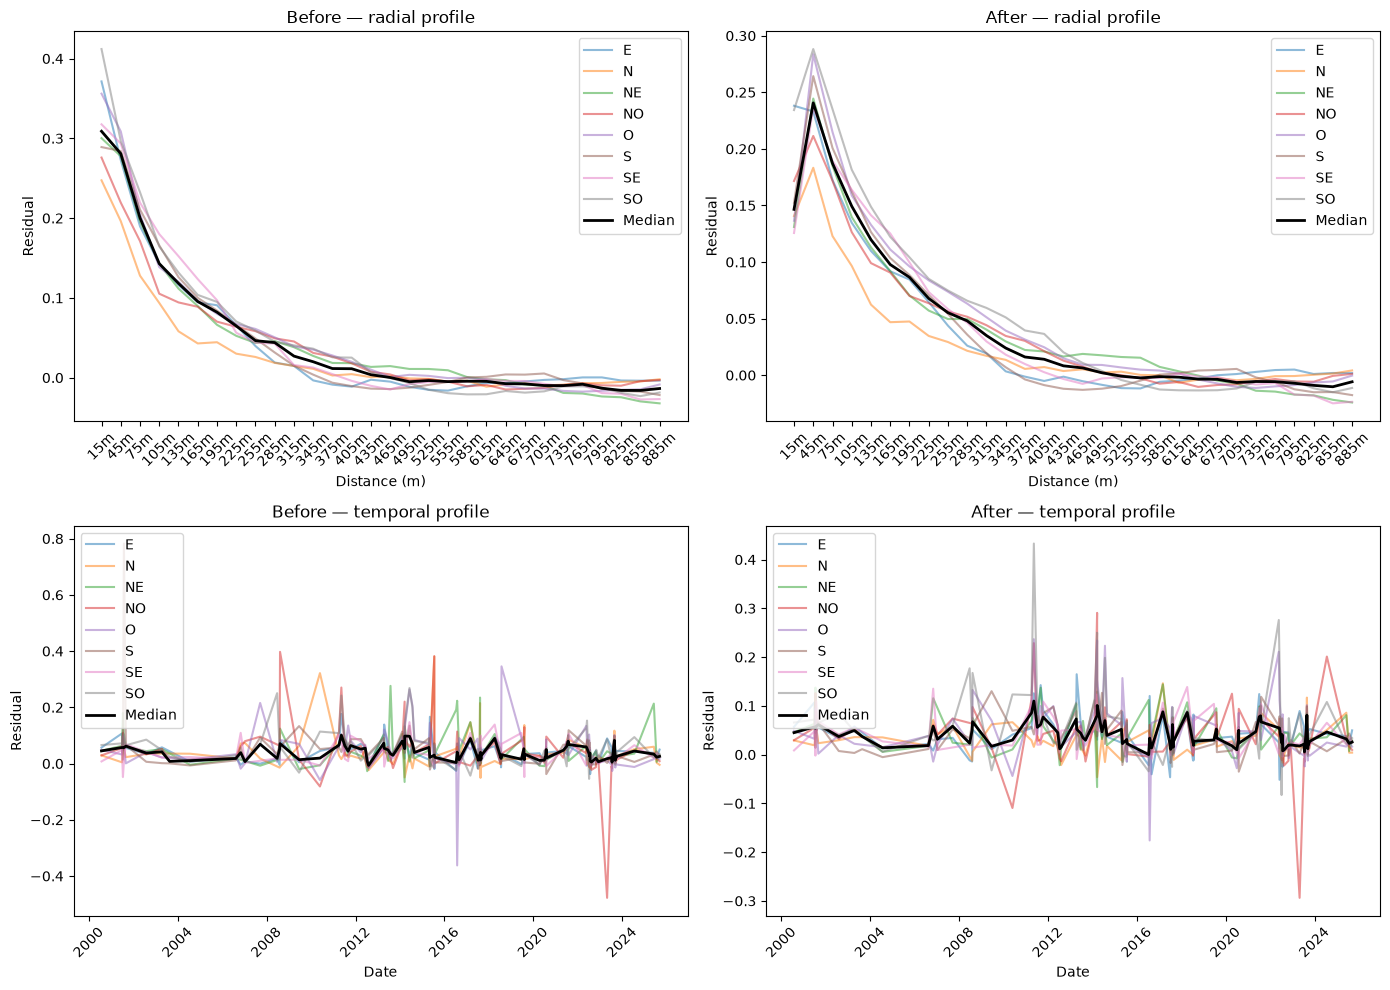

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

etna.plot.radial_profile(ax=axes[0, 0])
axes[0, 0].set_title("Before — radial profile")

imputed.plot.radial_profile(ax=axes[0, 1])
axes[0, 1].set_title("After — radial profile")

etna.plot.temporal_profile(ax=axes[1, 0])
axes[1, 0].set_title("Before — temporal profile")

imputed.plot.temporal_profile(ax=axes[1, 1])
axes[1, 1].set_title("After — temporal profile")

fig.tight_layout()

## Next steps

- [README.md](../README.md) for installation and a quick reference.
- `volcanicus.datasets.available()` for the full list of bundled datasets.
- `volcanicus.utils.AccessorABC` if you want to add your own accessor following the same `volcano.<accessor>(kind, **kwargs)` pattern used by `.plot` and `.stats`.
